In [ ]:
# /Users/nanaue/Documents/Projects/Portfolio/dataglancer.github.io/attackidentifier/data/
# '../../attackidentifier/data/Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet'
# /Users/nanaue/Documents/Projects/Portfolio/dataglancer.github.io/attackidentifier/data/Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet

# /Users/nanaue/Documents/Projects/Portfolio/dataglancer.github.io/attackidentifier/data/Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet

# /Users/nanaue/Documents/Projects/Portfolio/dataglancer.github.io/attackidentifier/data/DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet

#     /Users/nanaue/Documents/Projects/Portfolio/dataglancer.github.io/attackidentifier/data/DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet


#     /Users/nanaue/Documents/Projects/Portfolio/dataglancer.github.io/attackidentifier/data/Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
    
    

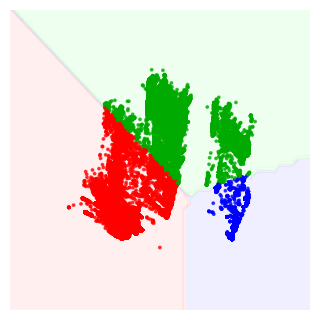

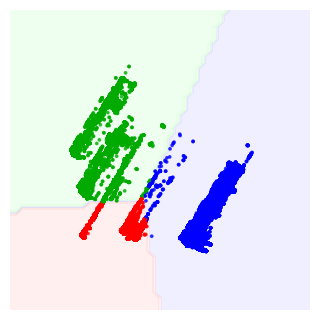

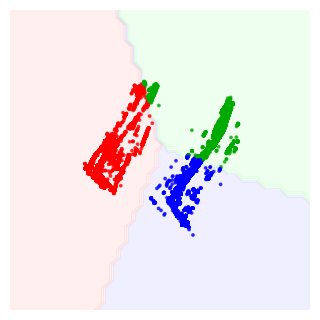

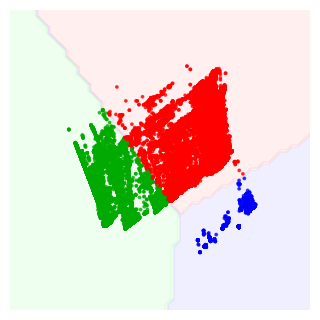

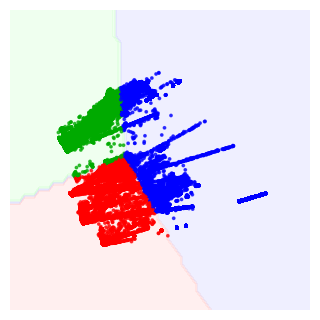

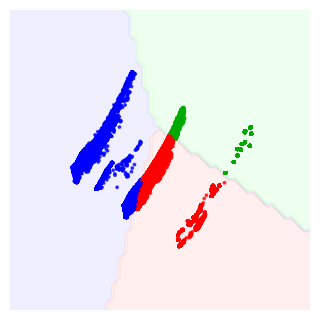

In [1]:
#Generate images from all attack files

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from imblearn.over_sampling import RandomOverSampler
from matplotlib.colors import ListedColormap

# Create output directory
output_dir = "attack_images"
os.makedirs(output_dir, exist_ok=True)


# Files to process
attack_files = {
    "Botnet-Friday": "../../attackidentifier/data/Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet",
    "Infil1-Wednesday": "../../attackidentifier/data/Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet",
    "Bruteforce-Wednesday": "../../attackidentifier/data/Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet",
    "DDoS1-Tuesday": "../../attackidentifier/data/DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet",
    "DoS1-Thursday": "../../attackidentifier/data/DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet",
    "Web1-Thursday": "../../attackidentifier/data/Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet"
}

# Loop over each attack
for name, path in attack_files.items():
    try:
        df = pd.read_parquet(path)
        X = df.drop('Label', axis=1).select_dtypes(include=[np.number])
        y = df['Label']

        # Oversample
        X_bal, y_bal = RandomOverSampler(random_state=42).fit_resample(X, y)

        # Normalize
        X_scaled = MinMaxScaler().fit_transform(X_bal)

        # PCA
        X_pca = PCA(n_components=2).fit_transform(X_scaled)

        # KMeans
        y_pred = KMeans(n_clusters=3, random_state=42).fit_predict(X_pca)

        # Mesh grid for decision boundary
        h = 0.1
        x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
        y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        Z = KMeans(n_clusters=3, random_state=42).fit(X_pca).predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot
        cmap_background = ListedColormap(['#FFCCCC', '#CCCCFF', '#CCFFCC'])
        cmap_points = ListedColormap(['#FF0000', '#0000FF', '#00AA00'])
        plt.figure(figsize=(3, 3), dpi=100)
        plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.3)
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap=cmap_points, s=3, alpha=0.7)
        plt.axis('off')
        plt.grid(True)
        plt.tight_layout(pad=0)

        # Save image
        plt.savefig(f"{output_dir}/{name}.png", dpi=100, bbox_inches='tight', pad_inches=0)
        plt.show()
        plt.close()
        
    except Exception as e:
        print(f"Error processing {name}: {e}")


[[236. 230. 228. ... 241. 241. 241.]
 [244. 244. 244. ... 241. 241. 241.]
 [248. 248. 248. ... 241. 241. 241.]
 [248. 248. 248. ... 241. 241. 241.]
 [248. 248. 248. ... 241. 241. 241.]
 [241. 241. 241. ... 244. 244. 244.]]
Explained variance ratio: [2.9578730e-01 2.2447485e-01 1.8741749e-01 1.5503408e-01 1.3728632e-01
 5.4550005e-09]


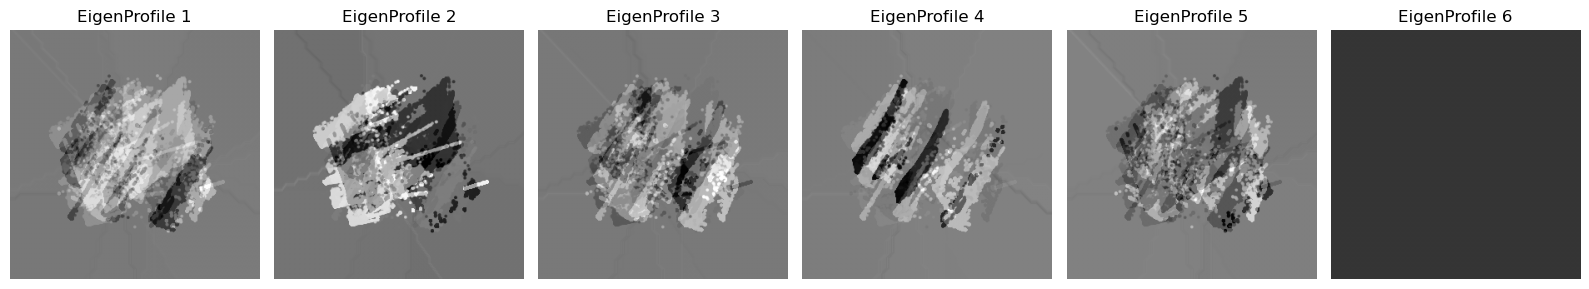

In [25]:
import os
import numpy as np
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Path to directory containing your 6 PNGs
image_dir = 'attack_images'
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])

# Load and flatten each image
image_vectors = []
for file in image_files:
    img = Image.open(os.path.join(image_dir, file)).convert('L')   # convert to grayscale
    img_resized = img.resize((300, 300))                           # ensure consistent size
    img_array = np.asarray(img_resized, dtype=np.float32).flatten()
    image_vectors.append(img_array)

# Stack all flattened images into a matrix
image_matrix = np.stack(image_vectors)
print(image_matrix)

# Perform PCA — set components to number of images (6 here)
n_components = len(image_files)  # Now handles 6 automatically
pca = PCA(n_components=n_components)
eigen_profiles = pca.fit(image_matrix)

# Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot eigenfaces
fig, axes = plt.subplots(1, n_components, figsize=(16, 3))
for i in range(n_components):
    axes[i].imshow(pca.components_[i].reshape(300, 300), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"EigenProfile {i+1}")
plt.tight_layout()
plt.show()


In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from imblearn.over_sampling import RandomOverSampler
from matplotlib.colors import ListedColormap

# Directories
input_base = "attack_data"
output_base = "attack_images_augmented"
os.makedirs(output_base, exist_ok=True)

# Parameters
num_augmentations = 5
noise_std = 0.02  # Small noise for Gaussian perturbation

# Loop over attack categories and files
for group in os.listdir(input_base):
    group_path = os.path.join(input_base, group)
    if not os.path.isdir(group_path):
        continue

    output_group_path = os.path.join(output_base, group)
    os.makedirs(output_group_path, exist_ok=True)

    for file in os.listdir(group_path):
        if not file.endswith(".parquet"):
            continue

        attack_name = file.replace(".parquet", "")
        full_path = os.path.join(group_path, file)

        try:
            df = pd.read_parquet(full_path)
            X = df.drop('Label', axis=1).select_dtypes(include=[np.number])
            y = df['Label']

            # Balance the data
            X_bal, y_bal = RandomOverSampler(random_state=42).fit_resample(X, y)

            # Normalize
            X_scaled = MinMaxScaler().fit_transform(X_bal)

            # PCA
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(X_scaled)

            for i in range(num_augmentations):
                # Apply Gaussian noise
                X_aug = X_pca + np.random.normal(0, noise_std, size=X_pca.shape)

                # KMeans clustering
                kmeans = KMeans(n_clusters=3, random_state=42)
                y_pred = kmeans.fit_predict(X_aug)

                # Create mesh grid for decision boundaries
                h = 0.1
                x_min, x_max = X_aug[:, 0].min() - 1, X_aug[:, 0].max() + 1
                y_min, y_max = X_aug[:, 1].min() - 1, X_aug[:, 1].max() + 1
                xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                                     np.arange(y_min, y_max, h))
                Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
                Z = Z.reshape(xx.shape)

                # Plot and save
                plt.figure(figsize=(3, 3), dpi=100)
                cmap_background = ListedColormap(['#FFCCCC', '#CCCCFF', '#CCFFCC'])
                cmap_points = ListedColormap(['#FF0000', '#0000FF', '#00AA00'])
                plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.3)
                plt.scatter(X_aug[:, 0], X_aug[:, 1], c=y_pred, cmap=cmap_points, s=3, alpha=0.7)
                plt.axis('off')
                plt.tight_layout(pad=0)

                # Save image
                filename = f"{attack_name}_aug{i+1}.png"
                plt.savefig(os.path.join(output_group_path, filename), dpi=100, bbox_inches='tight', pad_inches=0)
                plt.close()
                print(f"Saved: {filename}")

        except Exception as e:
            print(f"Error processing {file}: {e}")


Saved: Bruteforce-Wednesday_aug1.png
Saved: Bruteforce-Wednesday_aug2.png
Saved: Bruteforce-Wednesday_aug3.png
Saved: Bruteforce-Wednesday_aug4.png
Saved: Bruteforce-Wednesday_aug5.png
Saved: Infil1-Wednesday_aug1.png
Saved: Infil1-Wednesday_aug2.png
Saved: Infil1-Wednesday_aug3.png
Saved: Infil1-Wednesday_aug4.png
Saved: Infil1-Wednesday_aug5.png
Saved: Botnet-Friday_aug1.png
Saved: Botnet-Friday_aug2.png
Saved: Botnet-Friday_aug3.png
Saved: Botnet-Friday_aug4.png
Saved: Botnet-Friday_aug5.png
Saved: Infil2-Thursday_aug1.png
Saved: Infil2-Thursday_aug2.png
Saved: Infil2-Thursday_aug3.png
Saved: Infil2-Thursday_aug4.png
Saved: Infil2-Thursday_aug5.png
Saved: DDoS2-Wednesday_aug1.png
Saved: DDoS2-Wednesday_aug2.png
Saved: DDoS2-Wednesday_aug3.png
Saved: DDoS2-Wednesday_aug4.png
Saved: DDoS2-Wednesday_aug5.png
Saved: DoS2-Friday_aug1.png
Saved: DoS2-Friday_aug2.png
Saved: DoS2-Friday_aug3.png
Saved: DoS2-Friday_aug4.png
Saved: DoS2-Friday_aug5.png
Saved: DDoS1-Tuesday_aug1.png
Saved: DDo

[application] Image matrix shape: (10, 90000)
[application] Saved eigenfaces and mean face.


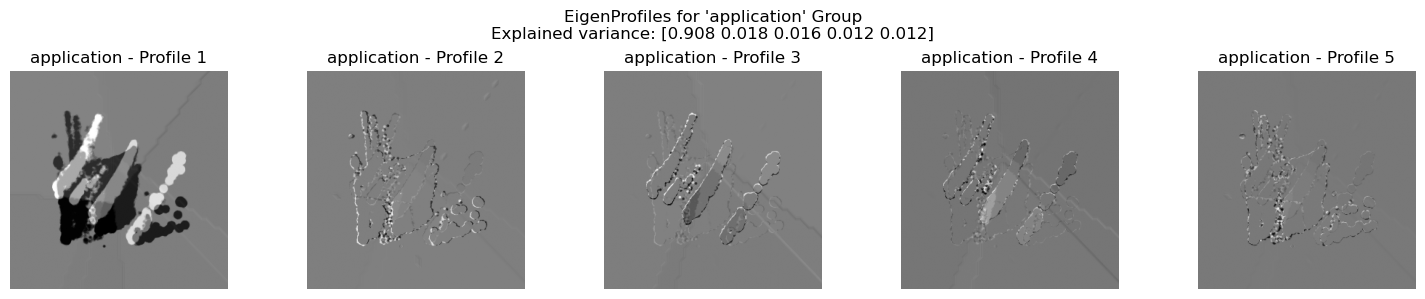

[credential] Image matrix shape: (5, 90000)
[credential] Saved eigenfaces and mean face.


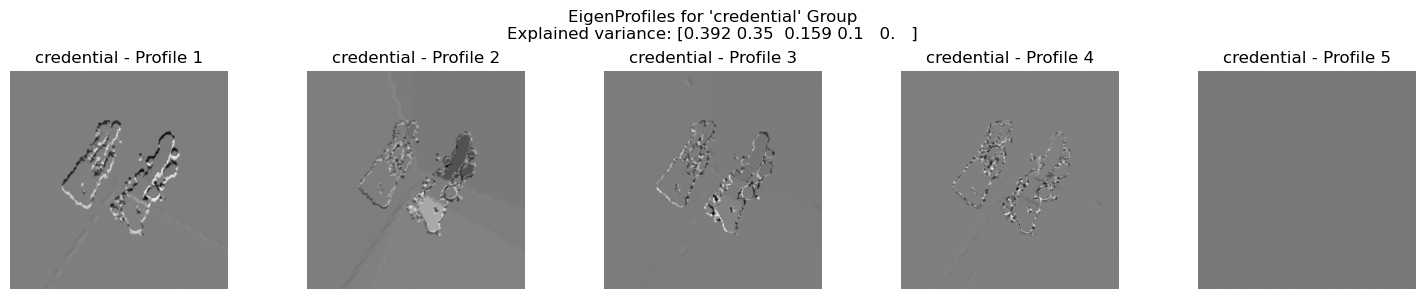

[denial] Image matrix shape: (20, 90000)
[denial] Saved eigenfaces and mean face.


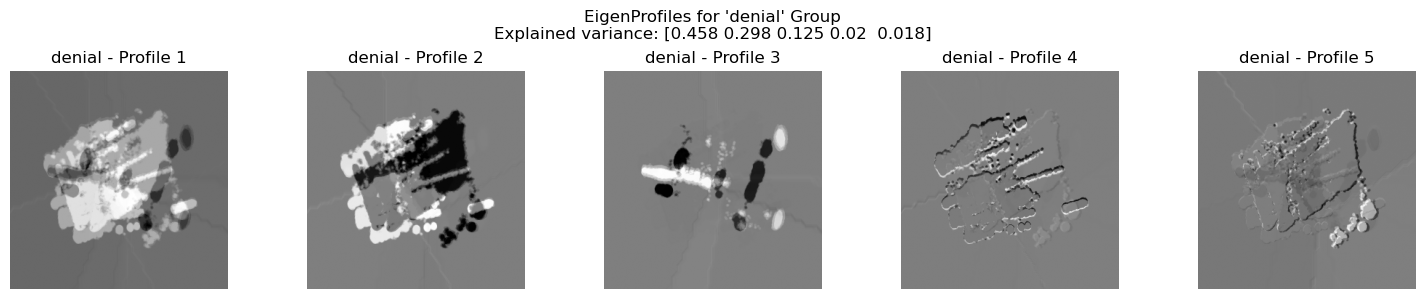

[exploit] Image matrix shape: (15, 90000)
[exploit] Saved eigenfaces and mean face.


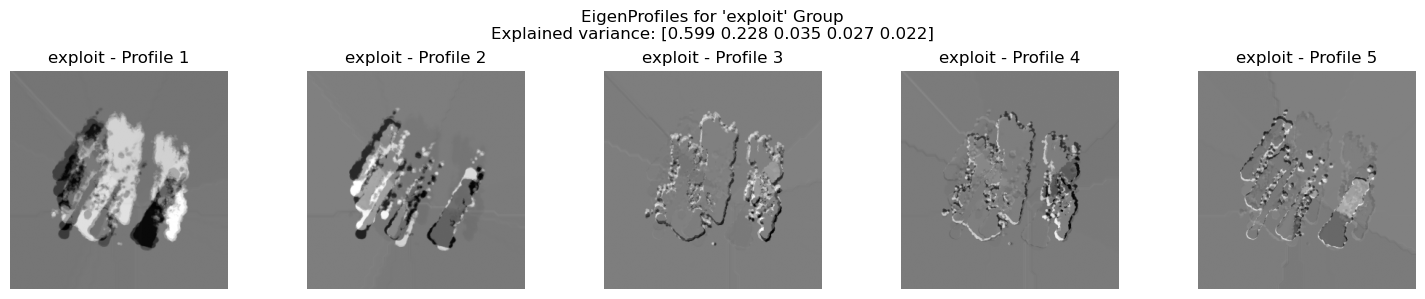

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from PIL import Image

# Configuration
IMAGE_DIR = "attack_images_augmented"
GROUPS = ["application", "credential", "denial", "exploit"]
IMG_SIZE = (300, 300)
NUM_COMPONENTS = 5

os.makedirs("eigen_models", exist_ok=True)
os.makedirs("mean_images", exist_ok=True)

for group in GROUPS:
    group_path = os.path.join(IMAGE_DIR, group)
    images = []

    for file in sorted(os.listdir(group_path)):
        if file.endswith('.png'):
            img = Image.open(os.path.join(group_path, file)).convert('L')
            img = img.resize(IMG_SIZE)
            img_arr = np.array(img).flatten()
            images.append(img_arr)

    X = np.vstack(images)
    print(f"[{group}] Image matrix shape: {X.shape}")

    pca = PCA(n_components=NUM_COMPONENTS)
    pca.fit(X)

    # Save eigenfaces and mean face
    np.save(f"eigen_models/{group}_eigenfaces.npy", pca.components_)
    np.save(f"mean_images/{group}_mean_face.npy", pca.mean_)
    print(f"[{group}] Saved eigenfaces and mean face.")

    # Visualize
    fig, axes = plt.subplots(1, NUM_COMPONENTS, figsize=(15, 3))
    for i, (ax, component) in enumerate(zip(axes, pca.components_)):
        ax.imshow(component.reshape(IMG_SIZE), cmap='gray')
        ax.set_title(f"{group} - Profile {i+1}")
        ax.axis('off')
    plt.suptitle(f"EigenProfiles for '{group}' Group\nExplained variance: {np.round(pca.explained_variance_ratio_, 3)}")
    plt.tight_layout()
    plt.savefig(f"eigen_'{group}'_profile.png")
    plt.show()


In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from imblearn.over_sampling import RandomOverSampler
from matplotlib.colors import ListedColormap

# Config
NUM_TEST_IMAGES = 3
TEST_SEED = 99
TEST_OUTPUT_DIR = "attack_images_test"
DATA_DIR = "attack_data"

# Same groupings
group_dirs = {
    "application": ["Web1-Thursday.parquet", "Web2-Friday.parquet"],
    "credential": ["Bruteforce-Wednesday.parquet"],
    "denial": ["DDoS1-Tuesday.parquet", "DDoS2-Wednesday.parquet", "DoS1-Thursday.parquet", "DoS2-Friday.parquet"],
    "exploit": ["Botnet-Friday.parquet", "Infil1-Wednesday.parquet", "Infil2-Thursday.parquet"]
}

# Colors
cmap_background = ListedColormap(['#FFCCCC', '#CCCCFF', '#CCFFCC'])
cmap_points = ListedColormap(['#FF0000', '#0000FF', '#00AA00'])

# Generate test images
for group, files in group_dirs.items():
    group_path = os.path.join(TEST_OUTPUT_DIR, group)
    os.makedirs(group_path, exist_ok=True)
    
    for fname in files:
        fpath = os.path.join(DATA_DIR, group, fname)
        df = pd.read_parquet(fpath)
        X = df.drop('Label', axis=1).select_dtypes(include=[np.number])
        y = df['Label']
        
        for i in range(1, NUM_TEST_IMAGES + 1):
            try:
                # Oversample
                X_bal, y_bal = RandomOverSampler(random_state=TEST_SEED + i).fit_resample(X, y)
                
                # Add new noise
                noise = np.random.normal(loc=0, scale=0.01, size=X_bal.shape)
                X_noisy = X_bal + noise

                # Scale
                X_scaled = MinMaxScaler().fit_transform(X_noisy)

                # PCA
                X_pca = PCA(n_components=2, random_state=TEST_SEED).fit_transform(X_scaled)

                # KMeans
                y_pred = KMeans(n_clusters=3, random_state=TEST_SEED).fit_predict(X_pca)

                # Mesh grid
                h = 0.1
                x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
                y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
                xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                                     np.arange(y_min, y_max, h))
                Z = KMeans(n_clusters=3, random_state=TEST_SEED).fit(X_pca).predict(np.c_[xx.ravel(), yy.ravel()])
                Z = Z.reshape(xx.shape)

                # Plot
                plt.figure(figsize=(3, 3), dpi=100)
                plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.3)
                plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap=cmap_points, s=3, alpha=0.7)
                plt.axis('off')
                plt.grid(True)
                plt.tight_layout(pad=0)

                # Save
                img_name = f"{fname.replace('.parquet','')}_test{i}.png"
                save_path = os.path.join(group_path, img_name)
                plt.savefig(save_path, dpi=100, bbox_inches='tight', pad_inches=0)
                plt.close()
                print(f"Saved test image: {save_path}")
                
            except Exception as e:
                print(f"Error with {fname}: {e}")


Saved test image: attack_images_test/application/Web1-Thursday_test1.png
Saved test image: attack_images_test/application/Web1-Thursday_test2.png
Saved test image: attack_images_test/application/Web1-Thursday_test3.png
Saved test image: attack_images_test/application/Web2-Friday_test1.png
Saved test image: attack_images_test/application/Web2-Friday_test2.png
Saved test image: attack_images_test/application/Web2-Friday_test3.png
Saved test image: attack_images_test/credential/Bruteforce-Wednesday_test1.png
Saved test image: attack_images_test/credential/Bruteforce-Wednesday_test2.png
Saved test image: attack_images_test/credential/Bruteforce-Wednesday_test3.png
Saved test image: attack_images_test/denial/DDoS1-Tuesday_test1.png
Saved test image: attack_images_test/denial/DDoS1-Tuesday_test2.png
Saved test image: attack_images_test/denial/DDoS1-Tuesday_test3.png
Saved test image: attack_images_test/denial/DDoS2-Wednesday_test1.png
Saved test image: attack_images_test/denial/DDoS2-Wednesd

In [32]:
#Compare each group's eigenfaces and assign it to the group that best reconstructs it. 
#For each image:
#1. Project the image onto each group's eigenface basis.
#2. Reconstruct the image from its projection
#3. Compute recconstruction error (e.g. L2 norm) 
#2 Assign the image to the group with the smallest error

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
from PIL import Image
import os

# Load PCA models (per group)
group_names = ['application', 'credential', 'denial', 'exploit']
eigen_models = {}
mean_images = {}

for group in group_names:
    # Load training images used to build PCA
    path = os.path.join('attack_images_augmented', group)
    images = []
    for fname in sorted(os.listdir(path)):
        img = Image.open(os.path.join(path, fname)).convert('L').resize((100, 100))
        images.append(np.asarray(img).flatten())
    
    X = np.array(images)
    mean_img = np.mean(X, axis=0)
    pca = PCA(n_components=5).fit(X - mean_img)

    eigen_models[group] = pca
    mean_images[group] = mean_img


In [12]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def classify_attack_image(image_path, eigen_models, mean_images, save_visual=True, output_dir="reconstruction_visuals"):
    img = Image.open(image_path).convert('L').resize((100, 100))
    x = np.asarray(img).flatten()

    best_group = None
    lowest_error = float('inf')
    best_recon = None

    for group, pca in eigen_models.items():
        mean = mean_images[group]
        x_centered = x - mean

        # Project and reconstruct
        x_proj = pca.transform([x_centered])
        x_recon = pca.inverse_transform(x_proj) + mean

        # Compute L2 reconstruction error
        error = np.linalg.norm(x - x_recon)

        if error < lowest_error:
            lowest_error = error
            best_group = group
            best_recon = x_recon

    # Optional: Save original vs reconstructed image
    if save_visual:
        os.makedirs(output_dir, exist_ok=True)
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        axes[0].imshow(x.reshape(100, 100), cmap='gray')
        axes[0].set_title('Original')
        axes[0].axis('off')

        axes[1].imshow(best_recon.reshape(100, 100), cmap='gray')
        axes[1].set_title('Reconstructed')
        axes[1].axis('off')

        filename = os.path.basename(image_path).replace('.png', f'_comparison_{best_group}.png')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, filename), dpi=150)
        plt.close()

    return best_group, lowest_error


In [13]:
test_root = 'attack_images_test'

results = []
for group in group_names:
    test_dir = os.path.join(test_root, group)
    for fname in os.listdir(test_dir):
        fpath = os.path.join(test_dir, fname)
        predicted_group, error = classify_attack_image(fpath, eigen_models, mean_images)
        results.append((fname, group, predicted_group, error))
        print(f"{fname}: actual={group} | predicted={predicted_group} | error={error:.2f}")


Web2-Friday_test1.png: actual=application | predicted=application | error=2767.61
Web2-Friday_test3.png: actual=application | predicted=application | error=2981.84
Web2-Friday_test2.png: actual=application | predicted=application | error=2789.34
Web1-Thursday_test1.png: actual=application | predicted=application | error=3050.41
Web1-Thursday_test3.png: actual=application | predicted=application | error=2977.45
Web1-Thursday_test2.png: actual=application | predicted=application | error=2999.30
Bruteforce-Wednesday_test1.png: actual=credential | predicted=credential | error=3344.20
Bruteforce-Wednesday_test2.png: actual=credential | predicted=credential | error=3270.69
Bruteforce-Wednesday_test3.png: actual=credential | predicted=credential | error=3227.02
DDoS2-Wednesday_test2.png: actual=denial | predicted=denial | error=1926.01
DoS2-Friday_test1.png: actual=denial | predicted=denial | error=2964.78
DDoS2-Wednesday_test3.png: actual=denial | predicted=denial | error=1908.37
DDoS2-Wedne

In [43]:
import pandas as pd

# Reconstruct results from your previous output
results = [
    ("Web2-Friday_test1.png", "application", "application", 2767.61),
    ("Web2-Friday_test3.png", "application", "application", 2981.84),
    ("Web2-Friday_test2.png", "application", "application", 2789.34),
    ("Web1-Thursday_test1.png", "application", "application", 3050.41),
    ("Web1-Thursday_test3.png", "application", "application", 2977.45),
    ("Web1-Thursday_test2.png", "application", "application", 2999.30),
    ("Bruteforce-Wednesday_test1.png", "credential", "credential", 3344.20),
    ("Bruteforce-Wednesday_test2.png", "credential", "credential", 3270.69),
    ("Bruteforce-Wednesday_test3.png", "credential", "credential", 3227.02),
    ("DDoS2-Wednesday_test2.png", "denial", "denial", 1926.01),
    ("DoS2-Friday_test1.png", "denial", "denial", 2964.78),
    ("DDoS2-Wednesday_test3.png", "denial", "denial", 1908.37),
    ("DDoS2-Wednesday_test1.png", "denial", "denial", 1913.15),
    ("DoS2-Friday_test2.png", "denial", "denial", 2965.25),
    ("DoS2-Friday_test3.png", "denial", "denial", 2964.54),
    ("DDoS1-Tuesday_test2.png", "denial", "denial", 3326.33),
    ("DoS1-Thursday_test2.png", "denial", "denial", 3654.82),
    ("DoS1-Thursday_test3.png", "denial", "denial", 3617.65),
    ("DDoS1-Tuesday_test3.png", "denial", "denial", 3962.46),
    ("DDoS1-Tuesday_test1.png", "denial", "denial", 3965.42),
    ("DoS1-Thursday_test1.png", "denial", "denial", 3689.68),
    ("Botnet-Friday_test1.png", "exploit", "exploit", 3728.97),
    ("Botnet-Friday_test2.png", "exploit", "exploit", 3129.00),
    ("Botnet-Friday_test3.png", "exploit", "exploit", 3134.76),
    ("Infil1-Wednesday_test1.png", "exploit", "exploit", 3503.59),
    ("Infil1-Wednesday_test3.png", "exploit", "exploit", 3661.05),
    ("Infil1-Wednesday_test2.png", "exploit", "exploit", 3686.89),
    ("Infil2-Thursday_test3.png", "exploit", "exploit", 3864.29),
    ("Infil2-Thursday_test2.png", "exploit", "exploit", 4074.26),
    ("Infil2-Thursday_test1.png", "exploit", "exploit", 3793.24),
]

error_data = pd.DataFrame(results, columns=["filename", "actual", "predicted", "error"])


In [44]:
display(error_data)

,filename,actual,predicted,error
0,Web2-Friday_test1.png,application,application,2767.61
1,Web2-Friday_test3.png,application,application,2981.84
2,Web2-Friday_test2.png,application,application,2789.34
3,Web1-Thursday_test1.png,application,application,3050.41
4,Web1-Thursday_test3.png,application,application,2977.45
5,Web1-Thursday_test2.png,application,application,2999.30
6,Bruteforce-Wednesday_test1.png,credential,credential,3344.20
7,Bruteforce-Wednesday_test2.png,credential,credential,3270.69
8,Bruteforce-Wednesday_test3.png,credential,credential,3227.02
9,DDoS2-Wednesday_test2.png,denial,denial,1926.01


/var/folders/1f/dzxl388543qbkp0jnhx1gnh40000gn/T/ipykernel_78243/804929788.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/1f/dzxl388543qbkp0jnhx1gnh40000gn/T/ipykernel_78243/804929788.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Attack Group", bbox_to_anchor=(1.05, 1), loc="upper left")


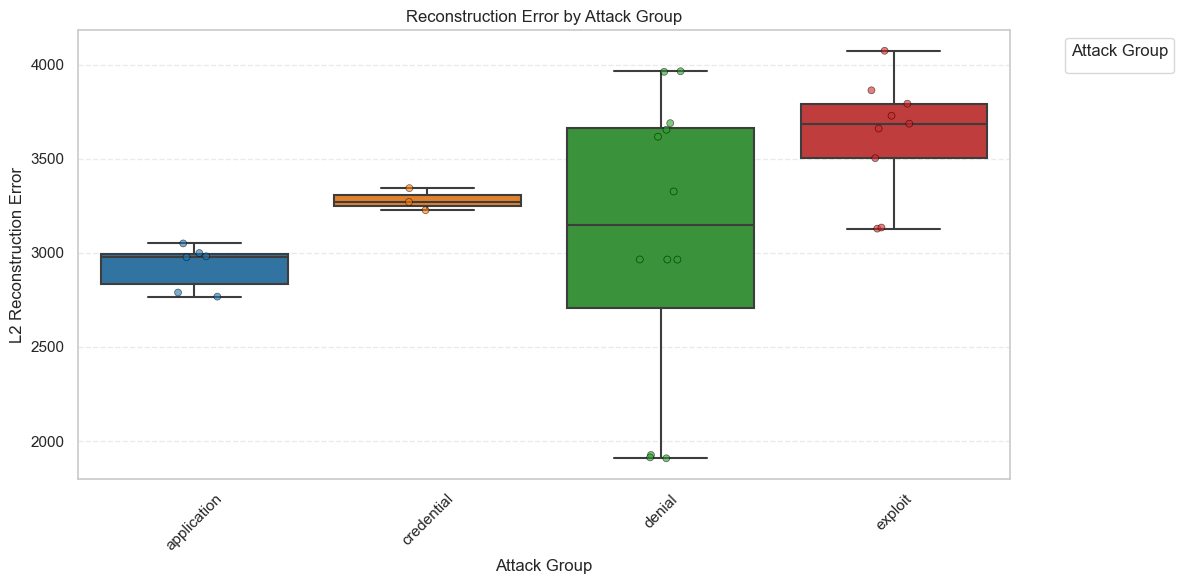

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure consistent style
sns.set(style="whitegrid")

# Create a DataFrame from your results list
error_data = pd.DataFrame(results, columns=["filename", "actual", "predicted", "error"])
error_data["correct"] = error_data["actual"] == error_data["predicted"]

# Define color palette for attack types
attack_groups = sorted(error_data["actual"].unique())
group_palette = dict(zip(attack_groups, sns.color_palette("tab10", n_colors=len(attack_groups))))

# Set up the plot
plt.figure(figsize=(12, 6))

# Boxplot: show error distribution per group
sns.boxplot(
    data=error_data,
    x="actual",
    y="error",
    palette=group_palette,
    linewidth=1.5
)

# Stripplot: overlay actual points
sns.stripplot(
    data=error_data,
    x="actual",
    y="error",
    hue="actual",
    palette=group_palette,
    dodge=False,
    marker="o",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.6
)

# Final touches
plt.title("Reconstruction Error by Attack Group")
plt.xlabel("Attack Group")
plt.ylabel("L2 Reconstruction Error")
plt.legend(title="Attack Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig('coloredreconerrobyattack.png')
plt.show()


Final benign matrix shape: (100000, 90000)
Processed 0 samples
Processed 5000 samples
Processed 10000 samples
Processed 15000 samples
Processed 20000 samples
Processed 25000 samples
Processed 30000 samples
Processed 35000 samples
Processed 40000 samples
Processed 45000 samples
Processed 50000 samples
Processed 55000 samples
Processed 60000 samples
Processed 65000 samples
Processed 70000 samples
Processed 75000 samples
Processed 80000 samples
Processed 85000 samples
Processed 90000 samples
Processed 95000 samples


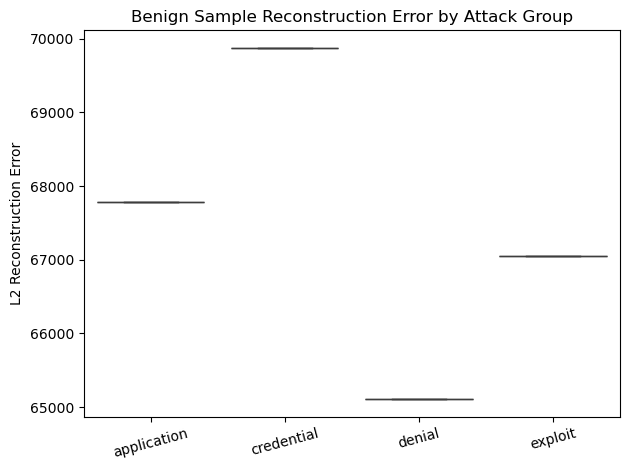

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from PIL import Image
import seaborn as sns
import pandas as pd

# Parameters
benign_parquet_path = 'remixed_data/benign_remix_100k.parquet'
model_root = 'eigen_models'
mean_root = 'mean_images'
attack_groups = ['application', 'credential', 'denial', 'exploit']

# Load eigen models and mean images
def load_eigen_data(group):
    eigenfaces = np.load(os.path.join(model_root, f"{group}_eigenfaces.npy"))
    mean_face = np.load(os.path.join(mean_root, f"{group}_mean_face.npy"))
    return eigenfaces, mean_face

# Simulate image projection from benign data
def normalize_to_image_vector(row, shape=(300, 300)):
    numeric_values = [val for val in row.values if isinstance(val, (int, float, np.integer, np.floating))]
    arr = np.array(numeric_values, dtype='float32')
    arr = np.nan_to_num(arr)

    # Clip & scale as image pixel-like input
    arr = np.clip(arr, 0, 255) / 255.0

    img_size = np.prod(shape)
    if arr.size < img_size:
        arr = np.pad(arr, (0, img_size - arr.size))
    elif arr.size > img_size:
        arr = arr[:img_size]
    return arr

    
# Load benign data
benign_df = pd.read_parquet(benign_parquet_path)


# Load & Normalize All Benign Vectors
benign_array = np.vstack(benign_df.apply(normalize_to_image_vector, axis=1))
print(f"Final benign matrix shape: {benign_array.shape}")



# Compute errors

all_errors = {group: [] for group in attack_groups}
benign_errors = []
for i, vec in enumerate(benign_array):
    best_error = float('inf')
    predicted_group = None



    for group in attack_groups:
        eigenfaces, mean_face = load_eigen_data(group)
        centered = vec - mean_face
        weights = np.dot(eigenfaces, centered)
        reconstruction = np.dot(weights, eigenfaces) + mean_face
        error = np.linalg.norm(vec - reconstruction)
        all_errors[group].append(error)

        if error < best_error:
            best_error = error
            predicted_group = group

    benign_errors.append((i, predicted_group, best_error))
    if i % 5000 == 0:
        print(f"Processed {i} samples")

# Plot distribution of benign errors per predicted group
error_df = pd.DataFrame(all_errors)
sns.boxplot(data=error_df)
plt.title("Benign Sample Reconstruction Error by Attack Group")
plt.ylabel("L2 Reconstruction Error")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

=== Inspecting Benign Data ===
Benign shape: (100000, 78)
Numeric cols: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag C

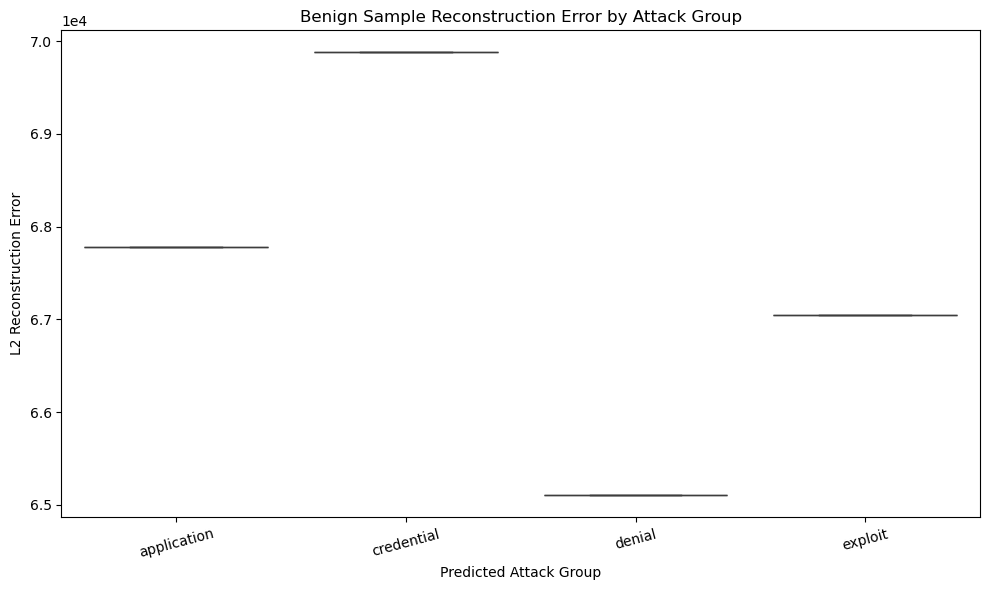

In [1]:
#latest version 
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from PIL import Image
import seaborn as sns
import pandas as pd

# Parameters
benign_parquet_path = 'remixed_data/benign_remix_100k.parquet'
model_root = 'eigen_models'
mean_root = 'mean_images'
attack_groups = ['application', 'credential', 'denial', 'exploit']
IMAGE_SHAPE = (300, 300)
NORMALIZE_AS_IMAGE = True  # Set to False if your PCA used raw float inputs

# Load eigen models and mean images
def load_eigen_data(group):
    eigenfaces = np.load(os.path.join(model_root, f"{group}_eigenfaces.npy"))
    mean_face = np.load(os.path.join(mean_root, f"{group}_mean_face.npy"))
    return eigenfaces, mean_face

# Normalize and reshape each row into a vector
def normalize_to_image_vector(row, shape=IMAGE_SHAPE):
    numeric_values = [val for val in row.values if isinstance(val, (int, float, np.integer, np.floating))]
    arr = np.array(numeric_values, dtype='float32')
    arr = np.nan_to_num(arr)

    if NORMALIZE_AS_IMAGE:
        arr = np.clip(arr, 0, 255) / 255.0  # Simulates pixel range
    # else: use raw floats

    img_size = np.prod(shape)
    if arr.size < img_size:
        arr = np.pad(arr, (0, img_size - arr.size))
    elif arr.size > img_size:
        arr = arr[:img_size]
    return arr

# Load benign data
benign_df = pd.read_parquet(benign_parquet_path)

# Inspect shape and types
print("=== Inspecting Benign Data ===")
print(f"Benign shape: {benign_df.shape}")
print(f"Numeric cols: {[col for col in benign_df.columns if pd.api.types.is_numeric_dtype(benign_df[col])]}")

# Convert all rows
benign_array = np.vstack(benign_df.apply(normalize_to_image_vector, axis=1))
print(f"Final benign matrix shape: {benign_array.shape}")

# Validate model dimensions
print("\n=== Validating Eigen Models ===")
for group in attack_groups:
    eigenfaces, mean_face = load_eigen_data(group)
    print(f"✔ {group:>10}: eigenfaces {eigenfaces.shape}, mean_face {mean_face.shape}")
    assert mean_face.shape[0] == benign_array.shape[1], f"Mismatch for {group}: mean vector length mismatch"

# Compute reconstruction errors
all_errors = {group: [] for group in attack_groups}
benign_errors = []

for i, vec in enumerate(benign_array):
    best_error = float('inf')
    predicted_group = None

    for group in attack_groups:
        eigenfaces, mean_face = load_eigen_data(group)

        centered = vec - mean_face
        weights = np.dot(eigenfaces, centered)
        reconstruction = np.dot(weights, eigenfaces) + mean_face
        error = np.linalg.norm(vec - reconstruction)
        all_errors[group].append(error)

        if error < best_error:
            best_error = error
            predicted_group = group

    benign_errors.append((i, predicted_group, best_error))
    if i % 5000 == 0:
        print(f"Processed {i} samples")

# Plot distribution of reconstruction errors
error_df = pd.DataFrame(all_errors)
plt.figure(figsize=(10, 6))
sns.boxplot(data=error_df)
plt.title("Benign Sample Reconstruction Error by Attack Group")
plt.ylabel("L2 Reconstruction Error")
plt.xlabel("Predicted Attack Group")
plt.xticks(rotation=15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.tight_layout()
plt.show()

# Optional: save for later analysis
error_df.to_csv("benign_reconstruction_errors.csv", index=False)


In [3]:
#Used for Toubleshooting only 
import os
import numpy as np
import pandas as pd

# CONFIG
benign_parquet_path = 'remixed_data/benign_remix_100k.parquet'
model_root = 'eigen_models'
mean_root = 'mean_images'
attack_groups = ['application', 'credential', 'denial', 'exploit']
IMG_SIZE = (300, 300)  # should match PCA training
expected_dim = np.prod(IMG_SIZE)

# Load and inspect eigen models
print("\n--- Checking Eigenface Models ---")
for group in attack_groups:
    try:
        eigenfaces = np.load(os.path.join(model_root, f"{group}_eigenfaces.npy"))
        mean_face = np.load(os.path.join(mean_root, f"{group}_mean_face.npy"))
        print(f"✔ {group}: eigenfaces {eigenfaces.shape}, mean_face {mean_face.shape}")
        assert eigenfaces.shape[1] == expected_dim, f"{group} eigenfaces dimension mismatch!"
        assert mean_face.shape[0] == expected_dim, f"{group} mean face dimension mismatch!"
    except Exception as e:
        print(f"✘ {group}: Failed to load → {e}")

# Load and inspect benign data
print("\n--- Inspecting Benign Data ---")
benign_df = pd.read_parquet(benign_parquet_path)
print(f"Benign shape: {benign_df.shape}")
print(f"Columns: {benign_df.columns[:5].tolist()} ...")
print(f"Types: {benign_df.dtypes.value_counts()}")

# Ensure consistent numeric column selection and scaling
numeric_cols = benign_df.select_dtypes(include=[np.number]).columns
print(f"Using {len(numeric_cols)} numeric columns")

# Sample one row to inspect range and dimensions
sample_vec = benign_df[numeric_cols].iloc[0].values.astype(np.float32)
print(f"Sample raw vector shape: {sample_vec.shape}, min={sample_vec.min()}, max={sample_vec.max()}")

# Preprocess the sample vector like in model
def normalize_to_image_vector(arr, shape=IMG_SIZE):
    arr = np.nan_to_num(arr)
    arr = np.clip(arr, 0, 255) / 255.0
    arr = arr.flatten()
    img_size = np.prod(shape)
    if arr.size < img_size:
        arr = np.pad(arr, (0, img_size - arr.size))
    elif arr.size > img_size:
        arr = arr[:img_size]
    return arr

processed_sample = normalize_to_image_vector(sample_vec)
print(f"Processed sample shape: {processed_sample.shape}, min={processed_sample.min()}, max={processed_sample.max()}")

# Check projection + reconstruction for all groups
print("\n--- Sample Reconstruction Errors ---")
for group in attack_groups:
    try:
        eigenfaces = np.load(os.path.join(model_root, f"{group}_eigenfaces.npy"))
        mean_face = np.load(os.path.join(mean_root, f"{group}_mean_face.npy"))
        centered = processed_sample - mean_face
        weights = np.dot(eigenfaces, centered)
        reconstruction = np.dot(weights, eigenfaces) + mean_face
        error = np.linalg.norm(processed_sample - reconstruction)
        print(f"{group}: L2 error = {error:.2f}")
    except Exception as e:
        print(f"{group}: ❌ {e}")



--- Checking Eigenface Models ---
✔ application: eigenfaces (5, 90000), mean_face (90000,)
✔ credential: eigenfaces (5, 90000), mean_face (90000,)
✔ denial: eigenfaces (5, 90000), mean_face (90000,)
✔ exploit: eigenfaces (5, 90000), mean_face (90000,)

--- Inspecting Benign Data ---
Benign shape: (100000, 78)
Columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total'] ...
Types: float32     22
int8        21
int32       15
int16        9
int64        8
float64      2
category     1
Name: count, dtype: int64
Using 77 numeric columns
Sample raw vector shape: (77,), min=-1.0, max=1461538.5
Processed sample shape: (90000,), min=0.0, max=1.0

--- Sample Reconstruction Errors ---
application: L2 error = 67785.05
credential: L2 error = 69876.94
denial: L2 error = 65105.99
exploit: L2 error = 67047.15


Processing application attack: 1659629 rows
  Processed 0 rows
  Processed 5000 rows
  Processed 10000 rows
  Processed 15000 rows
  Processed 20000 rows
  Processed 25000 rows
  Processed 30000 rows
  Processed 35000 rows
  Processed 40000 rows
  Processed 45000 rows
  Processed 50000 rows
  Processed 55000 rows
  Processed 60000 rows
  Processed 65000 rows
  Processed 70000 rows
  Processed 75000 rows
  Processed 80000 rows
  Processed 85000 rows
  Processed 90000 rows
  Processed 95000 rows
  Processed 100000 rows
  Processed 105000 rows
  Processed 110000 rows
  Processed 115000 rows
  Processed 120000 rows
  Processed 125000 rows
  Processed 130000 rows
  Processed 135000 rows
  Processed 140000 rows
  Processed 145000 rows
  Processed 150000 rows
  Processed 155000 rows
  Processed 160000 rows
  Processed 165000 rows
  Processed 170000 rows
  Processed 175000 rows
  Processed 180000 rows
  Processed 185000 rows
  Processed 190000 rows
  Processed 195000 rows
  Processed 200000 ro

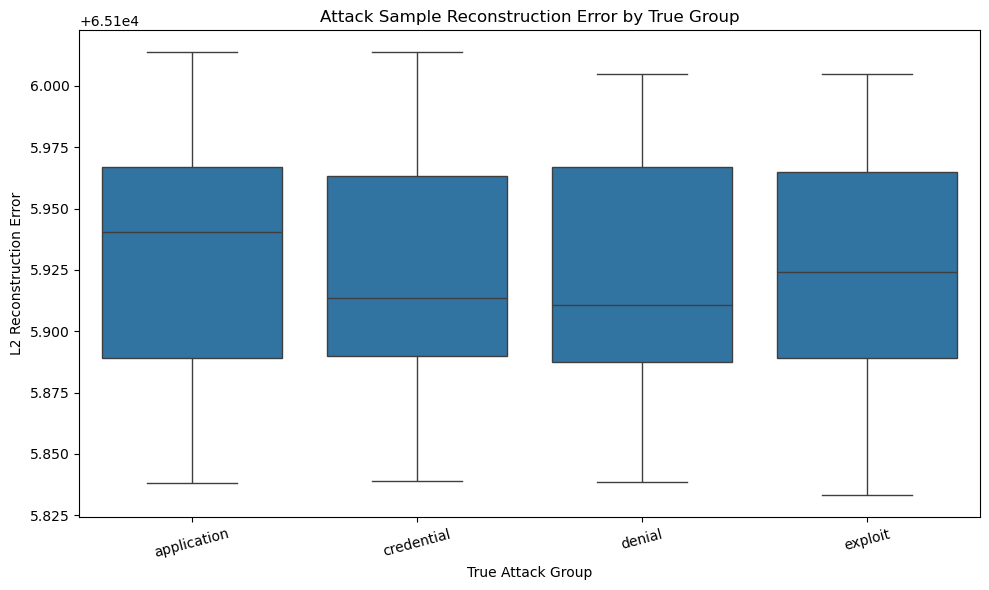

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths and config
attack_root = 'remixed_attack_data'
model_root = 'eigen_models'
mean_root = 'mean_images'
attack_groups = ['application', 'credential', 'denial', 'exploit']
IMG_SIZE = (300, 300)

# Load eigen data
def load_eigen_data(group):
    eigenfaces = np.load(os.path.join(model_root, f"{group}_eigenfaces.npy"))
    mean_face = np.load(os.path.join(mean_root, f"{group}_mean_face.npy"))
    return eigenfaces, mean_face

# Normalize row into image-like vector
def normalize_row(row, shape=IMG_SIZE):
    numeric_values = [val for val in row.values if isinstance(val, (int, float, np.integer, np.floating))]
    arr = np.array(numeric_values, dtype='float32')
    arr = np.nan_to_num(arr)
    arr = np.clip(arr, 0, 255) / 255.0
    flat_size = np.prod(shape)
    if arr.size < flat_size:
        arr = np.pad(arr, (0, flat_size - arr.size))
    elif arr.size > flat_size:
        arr = arr[:flat_size]
    return arr

# Storage for all reconstruction errors
error_records = []

for true_group in attack_groups:
    file_path = os.path.join(attack_root, f"{true_group}_attack.parquet")
    df = pd.read_parquet(file_path)
    print(f"Processing {true_group} attack: {len(df)} rows")

    for i, row in df.iterrows():
        vec = normalize_row(row)
        best_error = float('inf')
        best_group = None

        for model_group in attack_groups:
            eigenfaces, mean_face = load_eigen_data(model_group)
            centered = vec - mean_face
            weights = np.dot(eigenfaces, centered)
            reconstruction = np.dot(weights, eigenfaces) + mean_face
            error = np.linalg.norm(vec - reconstruction)

            if error < best_error:
                best_error = error
                best_group = model_group

        error_records.append((true_group, best_group, best_error))

        if i % 5000 == 0:
            print(f"  Processed {i} rows")

# Analyze and plot
error_df = pd.DataFrame(error_records, columns=["true_group", "predicted_group", "error"])

plt.figure(figsize=(10, 6))
sns.boxplot(data=error_df, x='true_group', y='error')
plt.title("Attack Sample Reconstruction Error by True Group")
plt.ylabel("L2 Reconstruction Error")
plt.xlabel("True Attack Group")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



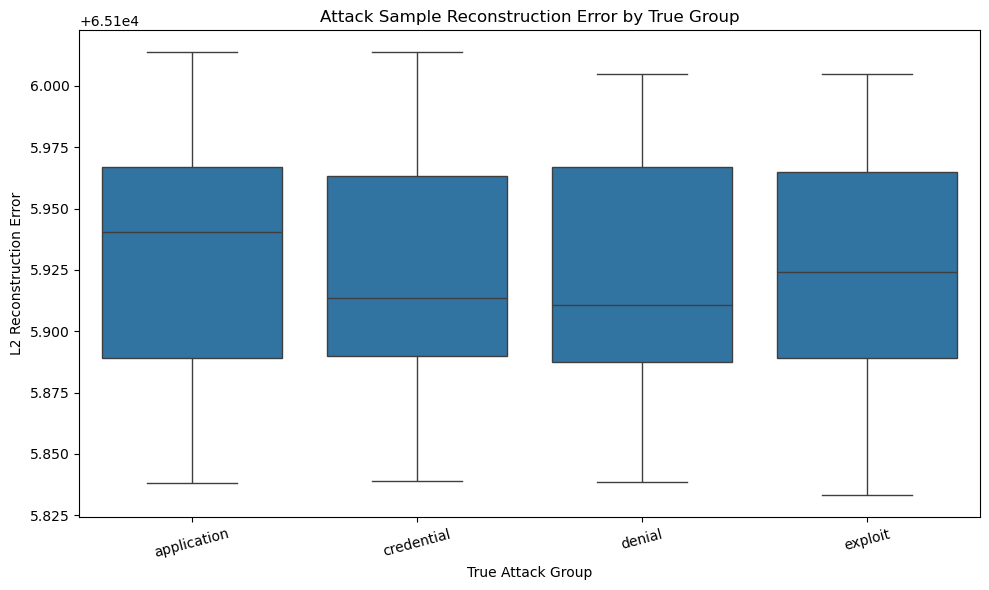

In [4]:
error_df = pd.DataFrame(error_records, columns=["true_group", "predicted_group", "error"])

plt.figure(figsize=(10, 6))
sns.boxplot(data=error_df, x='true_group', y='error')
plt.title("Attack Sample Reconstruction Error by True Group")
plt.ylabel("L2 Reconstruction Error")
plt.xlabel("True Attack Group")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('attacksamplereconstructionerror.png')
plt.show()

In [5]:
benignerrordf = pd.read_csv("benign_reconstruction_errors.csv")

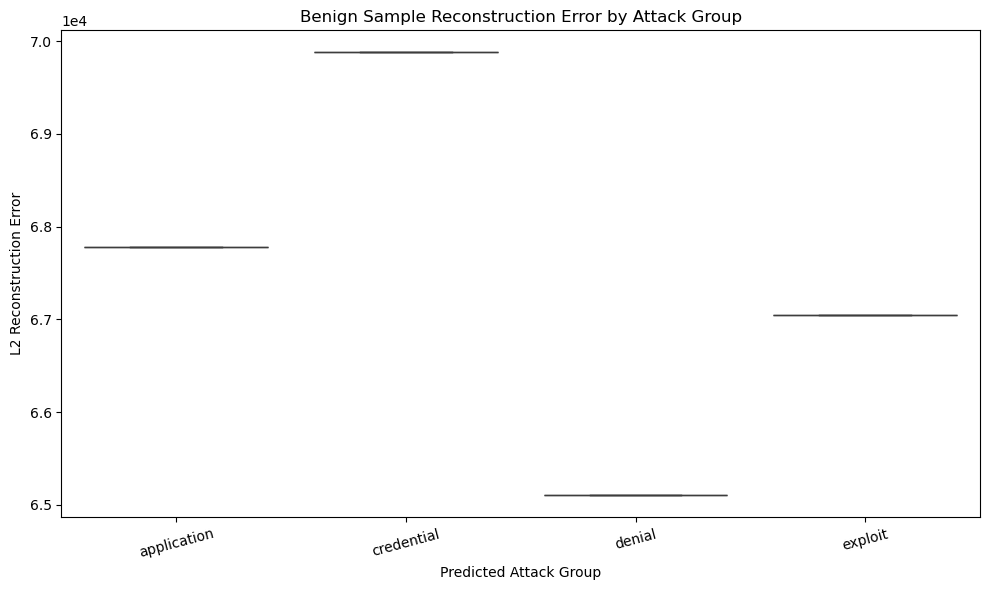

In [6]:
# Plot distribution of reconstruction errors

plt.figure(figsize=(10, 6))
sns.boxplot(data=benignerrordf)
plt.title("Benign Sample Reconstruction Error by Attack Group")
plt.ylabel("L2 Reconstruction Error")
plt.xlabel("Predicted Attack Group")
plt.xticks(rotation=15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.tight_layout()
plt.savefig('benignerrorresults.png')
plt.show()
